# **Linopy** in a nutshell

Check installation and availability of solver  

In [ ]:
import linopy
import highspy

# If no error message occurs then it's correctly installed
print(highspy.Highs())

# It should then show ['highs']
print(linopy.available_solvers)

['highs']


Solve an easy optimizing problem (see https://linopy.readthedocs.io/en/latest/create-a-model.html)    

Minimize: x + 2y

Subject to: 
- x >= 0
- y >= 0
- 3x + 7y >= 10
- 5x + 2y >= 3 

In [19]:
from linopy import Model

# 1) Initialize the model
m = linopy.Model()

# 2) Add variables
# You can assign a lower and upper bounds for your variables. The default is unbounded.
# The name argument is optional but can be useful for referencing the variables later
x = m.add_variables(lower=0, name="x")
y = m.add_variables(lower=0, name="y") 

# 3) Add Constraints
m.add_constraints(3 * x + 7 * y >= 10)
m.add_constraints(5 * x + 2 * y >= 3);

# 4) Add the objective function
m.add_objective(x + 2 * y)

# 5) Solve the model
status, termination = m.solve(solver_name="highs", output_flag=True)

print(status)       # 'ok'
print(termination)  # 'optimal'

# Some useful information like solution and runtime 
m.solution
# print(x.solution)
# print(y.solution)
# m.solver
# m.solver.report


ok
optimal


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    x        float64 8B 0.03448
    y        float64 8B 1.414

Now solve an optimizing problem using coordinates (see https://linopy.readthedocs.io/en/latest/create-a-model-with-coordinates.html)

Minimize: sum x_t + 2y_t

Subject to: 
- x >= 0
- y >= 0
- 3x_t + 7y_t >= 10*t
- 5x_t + 2y_t >= 3*t        
forall t whereas t spans all the range from 0 to 10.

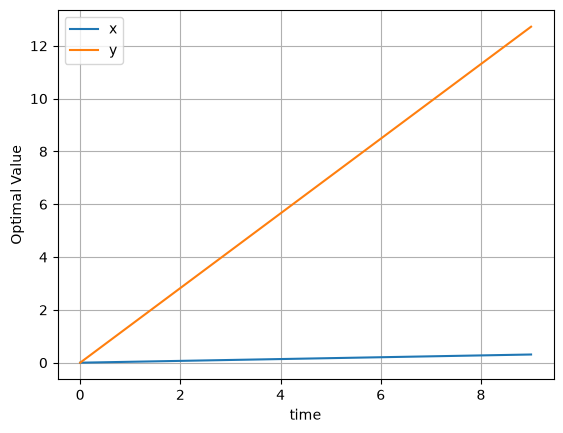

In [33]:
import linopy
import pandas as pd

# 1) Initialize model
m = linopy.Model()

# 2) Add variables with coordinates
time = pd.Index(range(10), name="time")     # <class 'pandas.RangeIndex'>: RangeIndex(start=0, stop=10, step=1, name='time')

x = m.add_variables(
    lower=0,
    coords=[time],
    name="x",
)
y = m.add_variables(
    lower=0, 
    coords=[time], 
    name="y"
)

# 3) Add constraints
factor = pd.Series(time, index=time)

con1 = m.add_constraints(3 * x + 7 * y >= 10 * factor, name="con1")
con2 = m.add_constraints(5 * x + 2 * y >= 3 * factor, name="con2")
# See model
# m
# Output:
# Linopy LP model
# ===============

# Variables:
# ----------
#  * x (time)
#  * y (time)

# Constraints:
# ------------
#  * con1 (time)
#  * con2 (time)

# Status:
# -------
# initialized

# 4) Add objective function
obj = (x + 2 * y).sum()
m.add_objective(obj)

# 5) Solve the model
m.solve(solver_name="highs", output_flag=False)

# To show solution use
# m.solution
# or 
m.solution.to_dataframe().plot(grid=True, ylabel="Optimal Value");

Creating variables (advanced)

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr

from linopy import Model

m = Model()

lower = xr.DataArray([1, 2, 3], dims=["time"])
upper = xr.DataArray([10, 11, 12], dims=["station"])

# Set variable type to integer or binary with integer=True or binary=True (without lower and upper bounds). Default is continuous 
m.add_variables(lower, upper, name="supply")


<xarray.DataArray (time: 3)> Size: 24B
array([1, 2, 3])
Dimensions without coordinates: time


Variable (time: 3, station: 3)
------------------------------
[0, 0]: supply[0, 0] ∈ [1, 10]
[0, 1]: supply[0, 1] ∈ [1, 11]
[0, 2]: supply[0, 2] ∈ [1, 12]
[1, 0]: supply[1, 0] ∈ [2, 10]
[1, 1]: supply[1, 1] ∈ [2, 11]
[1, 2]: supply[1, 2] ∈ [2, 12]
[2, 0]: supply[2, 0] ∈ [3, 10]
[2, 1]: supply[2, 1] ∈ [3, 11]
[2, 2]: supply[2, 2] ∈ [3, 12]